# FWI · boundary compression robustness

`storage_dtype` shrinks the saved boundary wavefield (fp16/bf16 → 2 bytes/cell,
int8 → ~1 byte + a per-256-cell FP32 scale, ~3.9×) while **compute stays FP32** —
only the boundary *storage* is lossy.  This page confirms that the lossy storage
does **not** degrade a real inversion: the same Marmousi FWI is run under the full
`{gpu, cpu, disk} × {fp16, bf16, int8}` matrix (plus a `gpu·fp32` anchor) and the
loss curve, model-RMSE curve, and final inverted model are compared.

Both back-ends are covered: the compiled **`impl='c'`** path (the full
`{gpu, cpu, disk}` storage matrix) and the pure-PyTorch **`impl='eager'`** path
(gpu storage only), across the same dtypes — so the same lossy-storage robustness
is shown to hold whether the gradient comes from hand-written CUDA adjoints or
from autograd.

The full memory *footprint* across the gpu/cpu/disk matrix is in
[Memory strategies](07_memory_strategies.ipynb); §5 here adds a **runtime
breakdown** of where the eager-path GPU memory actually goes and how
`storage_dtype` shrinks the boundary share, alongside the inversion **quality**
that is this page's main focus.

## 1. Setup — Marmousi (25 m, 4 s) + observed data

In [1]:
import tempfile
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.propagator.options import MemoryOptions, BoundaryOptions
from sweep.signal import ricker
from sweep.datasets import load_marmousi, MARMOUSI_DH

dh, dt, nt = MARMOUSI_DH * 2, 0.002, 2000
freq, delay = 5.0, 0.20
nshots, nrec, batch_shots = 20, 200, 8
src_z, rec_z = 2, 4
lr, n_iter = 25.0, 30
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vp_true_np = load_marmousi('true')[::2, ::2].copy()
vp_init_np = load_marmousi('smooth')[::2, ::2].copy()
shape = vp_true_np.shape
src_x = np.linspace(shape[1] * 0.1, shape[1] * 0.9, nshots).astype(np.int64)
rec_x = np.linspace(0, shape[1] - 1, nrec).astype(np.int64)
t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq)
sources = np.stack([src_x, np.full(nshots, src_z, dtype=np.int64)], 1)
receivers = np.repeat(np.stack([rec_x, np.full(nrec, rec_z, dtype=np.int64)], 1)[None], nshots, 0)

# observed data: generated once in FP32 and shared by every config.
with torch.no_grad():
    solver_obs = PropTorch(Acoustic(device=device), shape=shape, dh=dh, dt=dt, nt=nt, impl='c')
    observed = solver_obs(wavelet, sources, receivers, models=[torch.tensor(vp_true_np, device=device)]).detach()
del solver_obs; torch.cuda.empty_cache()
print('device:', device, ' shape:', shape, ' observed:', tuple(observed.shape))

device: cuda  shape: (141, 681)  observed: (20, 2000, 200, 1)


## 2. Storage × dtype matrix · stochastic Adam FWI

Each config gets a fresh `PropTorch` with the chosen back-end (`impl`), boundary
`storage`, and `storage_dtype`, inverts the smooth start with Adam (`lr=25`,
`eps=1e-16`), and replays the **same** random shot-batch sequence
(`default_rng(0)`) so the only difference between runs is how the boundary is
stored for the gradient reconstruction.  `impl='c'` runs the
`{gpu,cpu,disk}×{fp16,bf16,int8}` matrix; `impl='eager'` adds `gpu×{fp32,fp16,bf16,int8}`
(pure-PyTorch boundary saving keeps the ring on-device).  The eager runs are
slower (autograd reconstruction) but exercise the identical storage path.

In [2]:
disk_dir = tempfile.mkdtemp(prefix='fwi_bdy_dtype_')

def mem_cfg(storage, dtype):
    kw = dict(storage=storage, storage_dtype=dtype)
    if storage in ('cpu', 'disk'):
        kw['transfer_interval'] = 8
    if storage == 'cpu':
        kw['pinned_memory'] = True
    if storage == 'disk':
        kw['disk_dir'] = disk_dir
    return MemoryOptions(strategy='boundary', boundary=BoundaryOptions(**kw))

# impl='c' (compiled CUDA) covers the full storage x dtype matrix; impl='eager'
# (pure-PyTorch boundary saving) supports gpu storage only, across the same dtypes.
configs = ([('c', 'gpu', 'fp32')]
           + [('c', s, d) for s in ('gpu', 'cpu', 'disk') for d in ('fp16', 'bf16', 'int8')]
           + [('eager', 'gpu', d) for d in ('fp32', 'fp16', 'bf16', 'int8')])
rmse = lambda a: float(np.sqrt(np.mean((a - vp_true_np) ** 2)))

results = {}
for impl, storage, dtype in configs:
    label = f'{impl}·{storage}·{dtype}'
    solver = PropTorch(Acoustic(device=device), shape=shape, dh=dh, dt=dt, nt=nt,
                       impl=impl, memory=mem_cfg(storage, dtype))
    vp = torch.tensor(vp_init_np, device=device, requires_grad=True)
    opt = torch.optim.Adam([vp], lr=lr, eps=1e-16)
    rng = np.random.default_rng(0)
    losses, rmses = [], [rmse(vp_init_np)]
    for _ in range(n_iter):
        idx = rng.choice(nshots, batch_shots, replace=False)
        opt.zero_grad()
        loss = (solver(wavelet, sources[idx], receivers[idx], models=[vp]) - observed[idx]).pow(2).mean()
        loss.backward(); opt.step()
        losses.append(float(loss.detach().cpu()))
        rmses.append(rmse(vp.detach().cpu().numpy()))
    results[label] = dict(impl=impl, storage=storage, dtype=dtype, losses=losses, rmses=rmses, vp=vp.detach().cpu().numpy())
    print(f"{label:18s} loss {losses[0]:.3e} -> {losses[-1]:.3e}   rmse {rmses[0]:.1f} -> {rmses[-1]:.1f}")
    del solver, vp, opt; torch.cuda.empty_cache()

c·gpu·fp32         loss 5.443e-02 -> 3.122e-03   rmse 357.3 -> 306.8


c·gpu·fp16         loss 5.443e-02 -> 3.122e-03   rmse 357.3 -> 306.8


c·gpu·bf16         loss 5.443e-02 -> 3.122e-03   rmse 357.3 -> 306.8


c·gpu·int8         loss 5.443e-02 -> 3.123e-03   rmse 357.3 -> 306.8


c·cpu·fp16         loss 5.443e-02 -> 3.122e-03   rmse 357.3 -> 306.8


...

c·disk·int8        loss 5.443e-02 -> 3.123e-03   rmse 357.3 -> 306.8


eager·gpu·fp32     loss 5.443e-02 -> 3.117e-03   rmse 357.3 -> 304.1


eager·gpu·fp16     loss 5.443e-02 -> 3.117e-03   rmse 357.3 -> 304.1


eager·gpu·bf16     loss 5.443e-02 -> 3.117e-03   rmse 357.3 -> 304.1


eager·gpu·int8     loss 5.443e-02 -> 3.117e-03   rmse 357.3 -> 304.2


## 3. Convergence — loss & model RMSE

Colour = dtype (fp32 black / fp16 blue / bf16 green / int8 red).  For `impl='c'`
the line style encodes storage (gpu solid / cpu dashed / disk dotted); the
`impl='eager'` curves (gpu only) are dash-dot with circle markers.  The curves
land on top of each other within each back-end: lossy compression leaves the
inversion trajectory unchanged, in both the compiled and the autograd path.

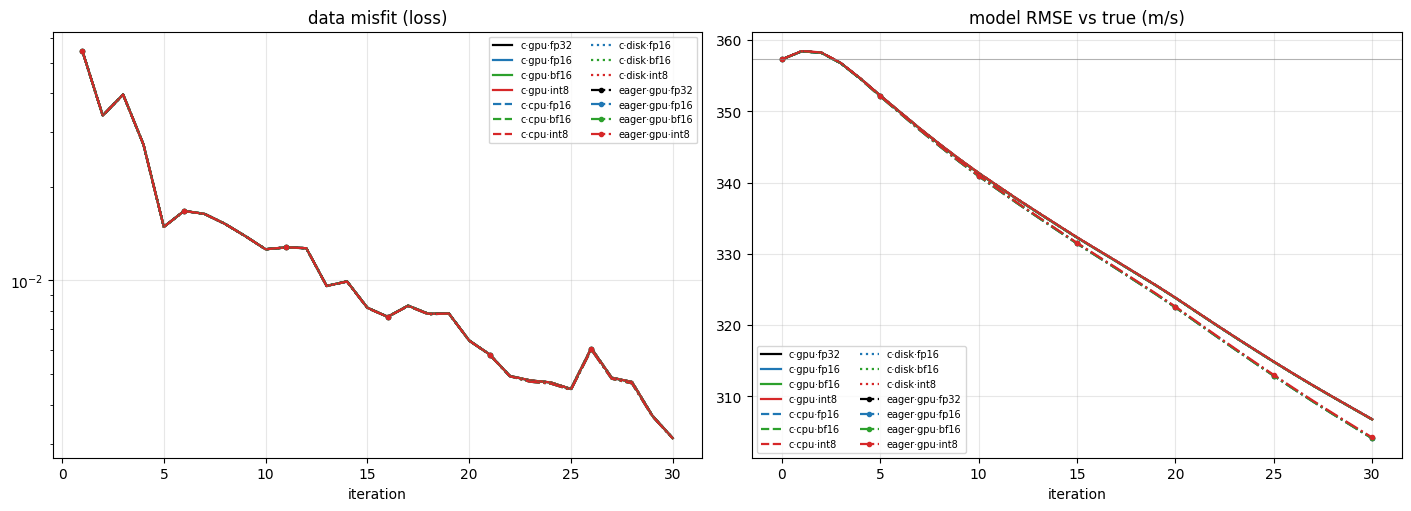

final loss / rmse per config:
  c·gpu·fp32         loss 3.122e-03   rmse 306.8
  c·gpu·fp16         loss 3.122e-03   rmse 306.8
  c·gpu·bf16         loss 3.122e-03   rmse 306.8
  c·gpu·int8         loss 3.123e-03   rmse 306.8
  c·cpu·fp16         loss 3.122e-03   rmse 306.8
  c·cpu·bf16         loss 3.122e-03   rmse 306.8
  c·cpu·int8         loss 3.123e-03   rmse 306.8
  c·disk·fp16        loss 3.122e-03   rmse 306.8
  c·disk·bf16        loss 3.122e-03   rmse 306.8
  c·disk·int8        loss 3.123e-03   rmse 306.8
  eager·gpu·fp32     loss 3.117e-03   rmse 304.1
  eager·gpu·fp16     loss 3.117e-03   rmse 304.1
  eager·gpu·bf16     loss 3.117e-03   rmse 304.1
  eager·gpu·int8     loss 3.117e-03   rmse 304.2


In [3]:
col = {'fp32': 'k', 'fp16': 'tab:blue', 'bf16': 'tab:green', 'int8': 'tab:red'}
ls = {'gpu': '-', 'cpu': '--', 'disk': ':'}
rmse0 = float(np.sqrt(np.mean((vp_init_np - vp_true_np) ** 2)))

def style(v):
    # colour = dtype; for impl='c' line style = storage; impl='eager' (gpu only)
    # is drawn dash-dot with markers so it reads apart from the c·gpu curves.
    if v['impl'] == 'eager':
        return dict(color=col[v['dtype']], ls='-.', lw=1.6, marker='o', markersize=3, markevery=5)
    return dict(color=col[v['dtype']], ls=ls[v['storage']], lw=1.6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for lbl, v in results.items():
    axes[0].plot(range(1, len(v['losses']) + 1), v['losses'], label=lbl, **style(v))
    axes[1].plot(range(len(v['rmses'])), v['rmses'], label=lbl, **style(v))
axes[0].set_yscale('log'); axes[0].set_title('data misfit (loss)'); axes[0].set_xlabel('iteration'); axes[0].grid(alpha=0.3)
axes[1].set_title('model RMSE vs true (m/s)'); axes[1].set_xlabel('iteration'); axes[1].grid(alpha=0.3)
axes[1].axhline(rmse0, color='gray', lw=0.8, alpha=0.6)
axes[0].legend(fontsize=7, ncol=2); axes[1].legend(fontsize=7, ncol=2)
plt.show()
print('final loss / rmse per config:')
for lbl, v in results.items():
    print(f"  {lbl:18s} loss {v['losses'][-1]:.3e}   rmse {v['rmses'][-1]:.1f}")

## 4. Final inverted models

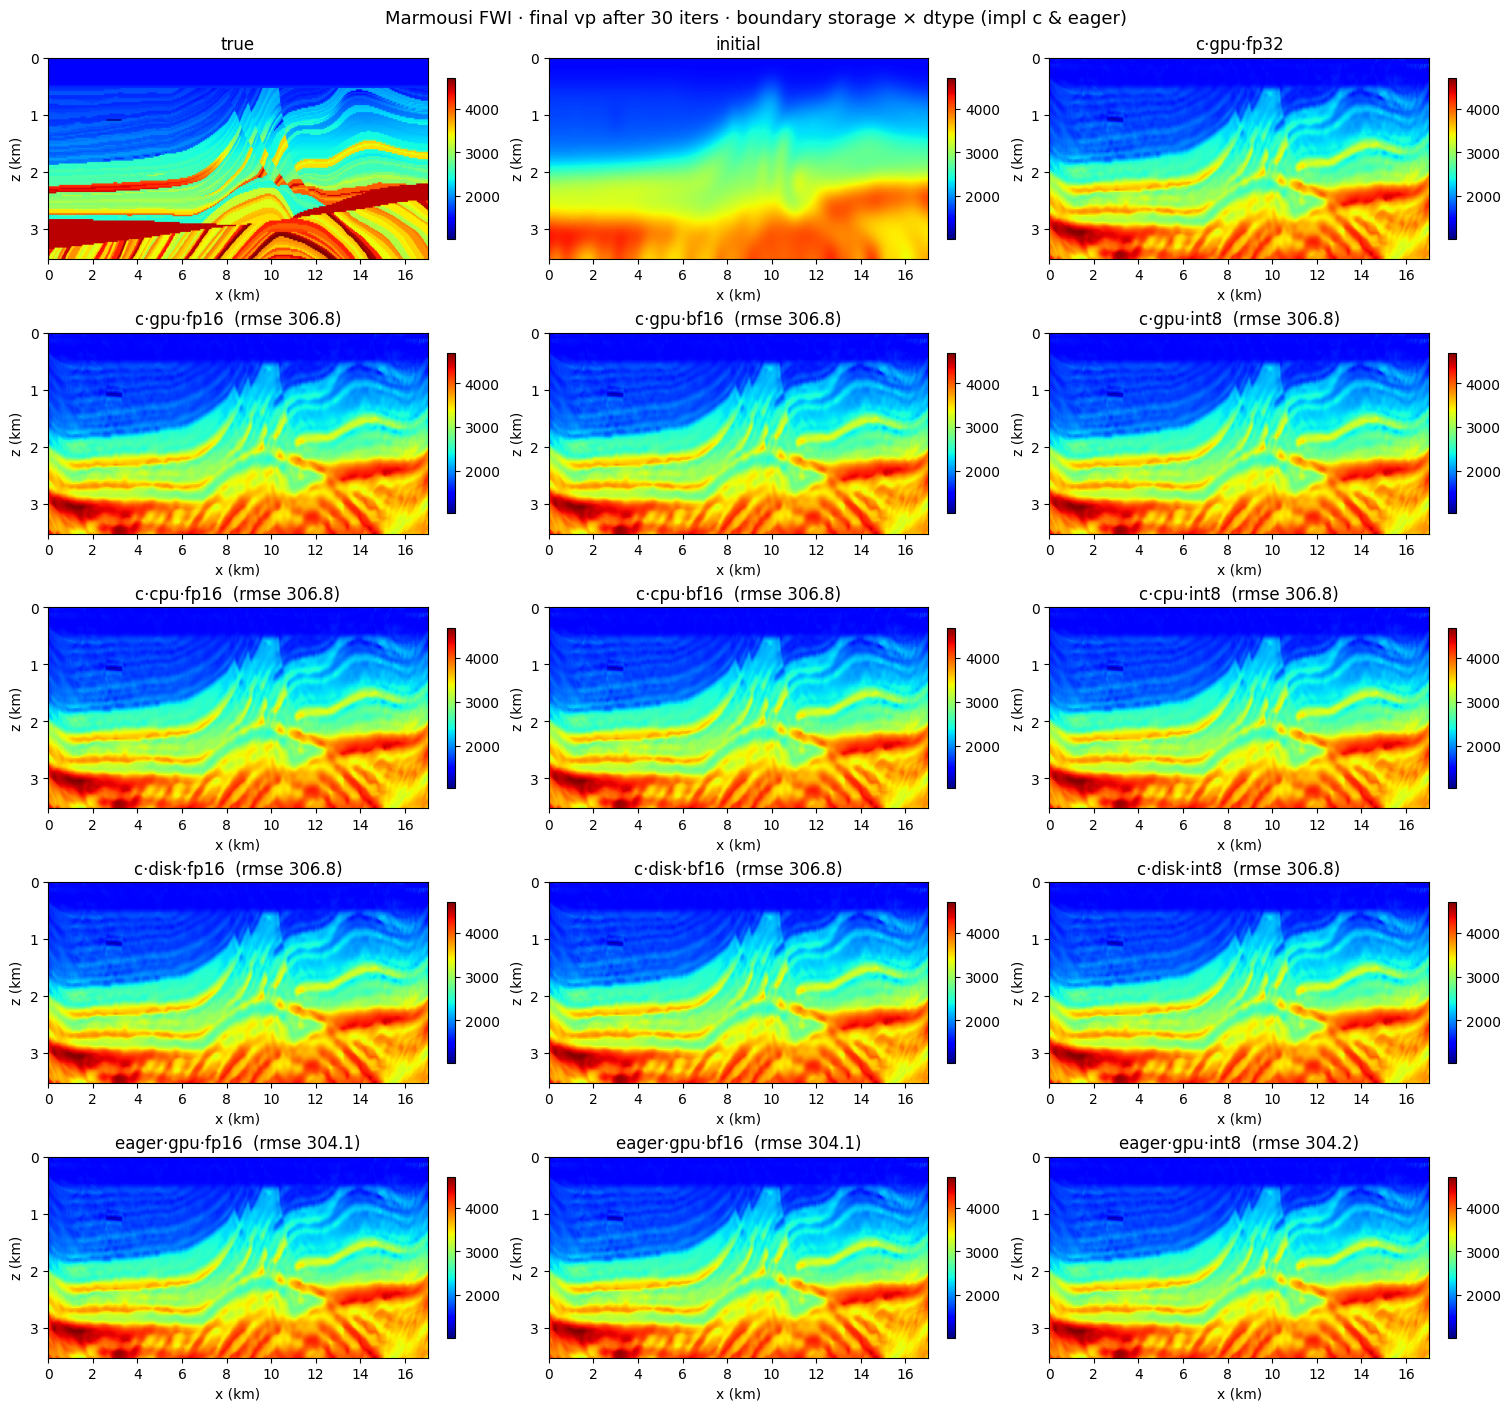

In [4]:
vmin, vmax = float(vp_true_np.min()), float(vp_true_np.max())
ext = [0, shape[1]*dh/1000, shape[0]*dh/1000, 0]
fig, axes = plt.subplots(5, 3, figsize=(15, 14), constrained_layout=True)
for ax, (ttl, m) in zip(axes[0], [('true', vp_true_np), ('initial', vp_init_np), ('c·gpu·fp32', results['c·gpu·fp32']['vp'])]):
    im = ax.imshow(m, cmap='jet', vmin=vmin, vmax=vmax, aspect='auto', extent=ext)
    ax.set_title(ttl); ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)'); fig.colorbar(im, ax=ax, shrink=0.8)
# rows: c·gpu / c·cpu / c·disk / eager·gpu, columns: fp16 / bf16 / int8
for r, (impl, storage) in enumerate([('c', 'gpu'), ('c', 'cpu'), ('c', 'disk'), ('eager', 'gpu')]):
    for c, dtype in enumerate(('fp16', 'bf16', 'int8')):
        ax = axes[r+1][c]; lbl = f'{impl}·{storage}·{dtype}'
        im = ax.imshow(results[lbl]['vp'], cmap='jet', vmin=vmin, vmax=vmax, aspect='auto', extent=ext)
        ax.set_title(f"{lbl}  (rmse {results[lbl]['rmses'][-1]:.1f})")
        ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)'); fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle(f'Marmousi FWI · final vp after {n_iter} iters · boundary storage × dtype (impl c & eager)', fontsize=13)
plt.show()

## 5. Runtime GPU memory breakdown (eager)

Where does the GPU memory actually go during an eager boundary-saving gradient,
and how much does `storage_dtype` move?  For a single Marmousi FWI iteration
(`B=8`, `nt=2000`) the live buffers are read back from the per-rollout
`ReconState` and `torch.cuda.max_memory_allocated()`, and the peak is split into:

* **boundary ring** — the per-step saved ring; the *only* part `storage_dtype` compresses;
* **working + context** — transient reconstruction/recompute graph, forward wavefields, PML coefficients, solver workspace (fixed);
* **seed frame** — the final wavefield snapshot that bootstraps the reverse march (always FP32);
* **observed data** and this iteration's **synthetic record**.

Only the boundary ring shrinks with the dtype — fp16/bf16 halve it, int8 quarters
it — so the peak drops while every other component stays put.

eager·gpu·fp32: peak  680.1 MB | working+ctx  350.6  seed  35.2  obs  30.5  rec  12.2  | boundary  251.6 (37.0%)


eager·gpu·fp16: peak  553.9 MB | working+ctx  350.2  seed  35.2  obs  30.5  rec  12.2  | boundary  125.8 (22.7%)


eager·gpu·bf16: peak  553.9 MB | working+ctx  350.2  seed  35.2  obs  30.5  rec  12.2  | boundary  125.8 (22.7%)


eager·gpu·int8: peak  492.1 MB | working+ctx  350.2  seed  35.2  obs  30.5  rec  12.2  | boundary   64.0 (13.0%)


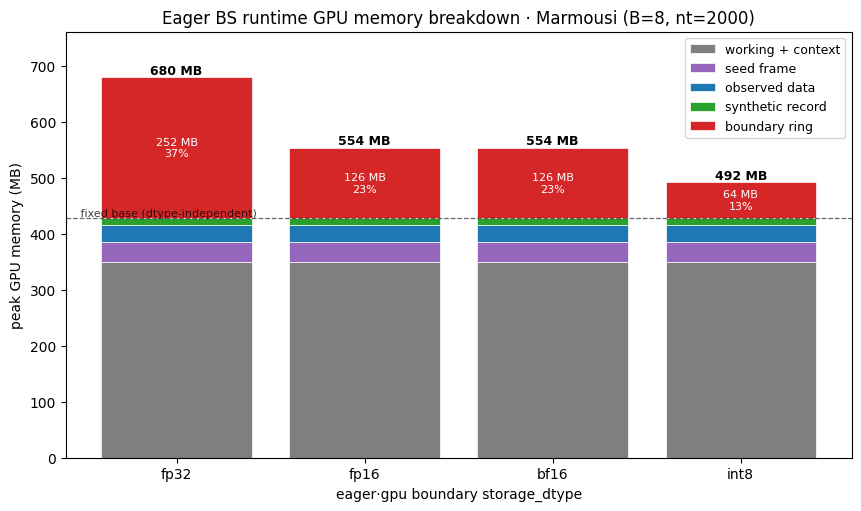

In [5]:
import gc
import torch._dynamo
import sweep.propagator._eager_boundary_saving as _ebs
from sweep.propagator.options import EagerOptions

# Reproducible breakdown: clear any compiled-step workspace left resident by
# earlier cells, and measure with use_compile=False — so the numbers depend only
# on this cell (re-running gives identical values, independent of run order).
torch._dynamo.reset(); gc.collect(); torch.cuda.empty_cache()

# Read the boundary ring buffer straight from the per-rollout ReconState (the
# eager path keeps it on-device as one tensor, or int8 codes+scale).
_seen = []
_orig_init = _ebs.ReconState.__init__
def _cap_init(self, *a, **k):
    _orig_init(self, *a, **k); _seen.append(self)
_ebs.ReconState.__init__ = _cap_init

_mb = lambda t: t.element_size() * t.nelement() / 2**20
def _ring_mb(st):
    return (_mb(st.codes) + _mb(st.scale)) if st.store_dtype == 'int8' else _mb(st.buf)

idx0 = np.arange(batch_shots)
obs_mb = _mb(observed)
mem_break = {}
for dtype in ('fp32', 'fp16', 'bf16', 'int8'):
    # release the previous config's ReconState/buffers before measuring this one
    _seen.clear(); gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    solver = PropTorch(Acoustic(device=device), shape=shape, dh=dh, dt=dt, nt=nt, impl='eager',
                       eager_options=EagerOptions(use_compile=False), memory=mem_cfg('gpu', dtype))
    vp = torch.tensor(vp_init_np, device=device, requires_grad=True)
    rec_out = solver(wavelet, sources[idx0], receivers[idx0], models=[vp])
    rec_mb = _mb(rec_out)
    (rec_out - observed[idx0]).pow(2).mean().backward()
    peak = torch.cuda.max_memory_allocated() / 2**20
    st = _seen[-1]
    bnd = _ring_mb(st); frame = sum(_mb(t) for t in st.frame)
    other = max(peak - bnd - frame - obs_mb - rec_mb, 0.0)
    mem_break[dtype] = dict(boundary=bnd, context=other, frame=frame, observed=obs_mb, record=rec_mb, peak=peak)
    print(f"eager·gpu·{dtype}: peak {peak:6.1f} MB | working+ctx {other:6.1f}  seed {frame:5.1f}"
          f"  obs {obs_mb:5.1f}  rec {rec_mb:5.1f}  | boundary {bnd:6.1f} ({100*bnd/peak:4.1f}%)")
    del solver, vp, rec_out, st; _seen.clear(); gc.collect(); torch.cuda.empty_cache()
_ebs.ReconState.__init__ = _orig_init

# Stacked bar — FIXED components (working+context, seed frame, observed, record)
# at the BOTTOM so their top edge is a level "fixed base" across all bars; the
# boundary ring sits on TOP, so its shrink with storage_dtype is obvious.
layers = [('working + context', 'context', 'tab:gray'),
          ('seed frame', 'frame', 'tab:purple'),
          ('observed data', 'observed', 'tab:blue'),
          ('synthetic record', 'record', 'tab:green'),
          ('boundary ring', 'boundary', 'tab:red')]
dtypes = list(mem_break)
fig, ax = plt.subplots(figsize=(8.5, 5), constrained_layout=True)
bottom = np.zeros(len(dtypes))
for label, key, color in layers:
    vals = np.array([mem_break[d][key] for d in dtypes])
    ax.bar(dtypes, vals, bottom=bottom, label=label, color=color, edgecolor='white', lw=0.5)
    if key == 'boundary':
        for i, d in enumerate(dtypes):
            ax.text(i, bottom[i] + vals[i] / 2, f"{vals[i]:.0f} MB\n{100*vals[i]/mem_break[d]['peak']:.0f}%",
                    ha='center', va='center', fontsize=8, color='white')
    bottom += vals
for i, d in enumerate(dtypes):
    ax.text(i, bottom[i] + 6, f'{bottom[i]:.0f} MB', ha='center', fontsize=9, fontweight='bold')
# the fixed base (everything except the boundary ring) is identical for every dtype
base = mem_break['fp32']['peak'] - mem_break['fp32']['boundary']
ax.axhline(base, color='k', ls='--', lw=0.9, alpha=0.6)
ax.text(0.015, base, ' fixed base (dtype-independent)', va='bottom', ha='left',
        fontsize=8, alpha=0.75, transform=ax.get_yaxis_transform())
ax.set_ylabel('peak GPU memory (MB)'); ax.set_xlabel('eager·gpu boundary storage_dtype')
ax.set_title(f'Eager BS runtime GPU memory breakdown · Marmousi (B={batch_shots}, nt={nt})')
ax.legend(loc='upper right', fontsize=9); ax.margins(y=0.12)
plt.show()

## Takeaway

All nine `{gpu, cpu, disk} × {fp16, bf16, int8}` compiled combinations track the
`c·gpu·fp32` anchor — and the pure-PyTorch `eager·gpu·{fp16,bf16,int8}` runs track
their own `eager·gpu·fp32` anchor just as tightly: identical loss decay, identical
model-RMSE convergence, visually indistinguishable final models.  Lossy boundary
storage (down to int8's ~3.9× compression) does not measurably harm acoustic FWI
here, in **either** back-end — pick the back-end/storage by your memory budget
([Memory strategies](07_memory_strategies.ipynb)) and the dtype by how aggressively
you need to shrink the boundary buffer.

---

**Download this notebook** &mdash; [`19_fwi_boundary_dtype.ipynb`](19_fwi_boundary_dtype.ipynb) &middot; or [view on GitHub](https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/19_fwi_boundary_dtype.ipynb)